# Heart Disease Risk Predictor
Hi, My name is Joaquin Carmona, and I'll be working on this project to predict the risk of heart disease. This notebook will be used to explore the data and perform EDA. I'll be learning as I go and using this notebook to document my progress, videos or documents I find useful, and any other resources I find helpful.  

My purpose with this project is to jump in the Healthcare AI world doing this basic project to get started. I'll be using different approaches and algorithms to predict the risk of heart disease.

## Dataset
This is a multivariate type of dataset which means providing or involving a variety of separate mathematical or statistical variables, multivariate numerical data analysis. It is composed of 14 attributes which are age, sex, chest pain type, resting blood pressure, serum cholesterol, fasting blood sugar, resting electrocardiographic results, maximum heart rate achieved, exercise-induced angina, oldpeak — ST depression induced by exercise relative to rest, the slope of the peak exercise ST segment, number of major vessels and Thalassemia. This database includes 76 attributes, but all published studies relate to the use of a subset of 14 of them. The Cleveland database is the only one used by ML researchers to date. One of the major tasks on this dataset is to predict based on the given attributes of a patient that whether that particular person has heart disease or not and other is the experimental task to diagnose and find out various insights from this dataset which could help in understanding the problem more.

## Reference
Detrano, R. et al. (1989). *International application of a new probability algorithm for the 
diagnosis of coronary artery disease.* American Journal of Cardiology, 64(5), 304-310.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    roc_auc_score, roc_curve, precision_recall_curve, average_precision_score
)

from xgboost import XGBClassifier

import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('heart_disease_uci.csv')

In [3]:
missing_pct = df.isnull().mean() * 100
print(missing_pct)
#first we check for null values, as we can see there are a lot of null values in the dataset, we will need to handle them, and 
# take the best decision for each case.

"""Features ca and thal were excluded from the predictive model due to >50% missingness,
driven by the high cost and invasive nature of fluoroscopy and thallium stress testing across the four contributing institutions.
Imputing over half the dataset for these features would introduce substantial uncertainty and clinical implausibility."""


id           0.000000
age          0.000000
sex          0.000000
dataset      0.000000
cp           0.000000
trestbps     6.413043
chol         3.260870
fbs          9.782609
restecg      0.217391
thalch       5.978261
exang        5.978261
oldpeak      6.739130
slope       33.586957
ca          66.413043
thal        52.826087
num          0.000000
dtype: float64


'Features ca and thal were excluded from the predictive model due to >50% missingness,\ndriven by the high cost and invasive nature of fluoroscopy and thallium stress testing across the four contributing institutions.\nImputing over half the dataset for these features would introduce substantial uncertainty and clinical implausibility.'

In [4]:
print(df.columns)

Index(['id', 'age', 'sex', 'dataset', 'cp', 'trestbps', 'chol', 'fbs',
       'restecg', 'thalch', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'num'],
      dtype='str')


<Axes: >

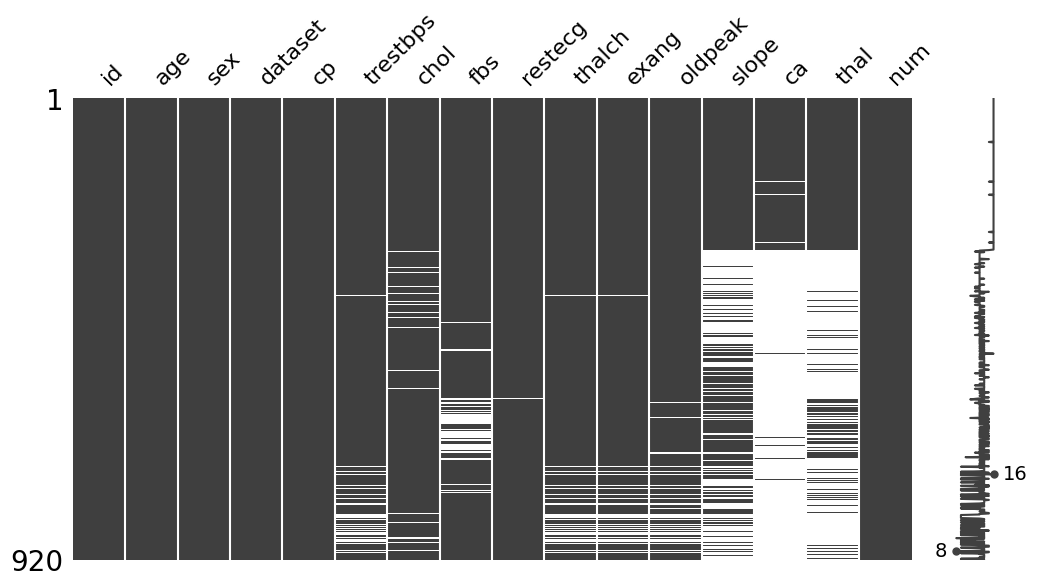

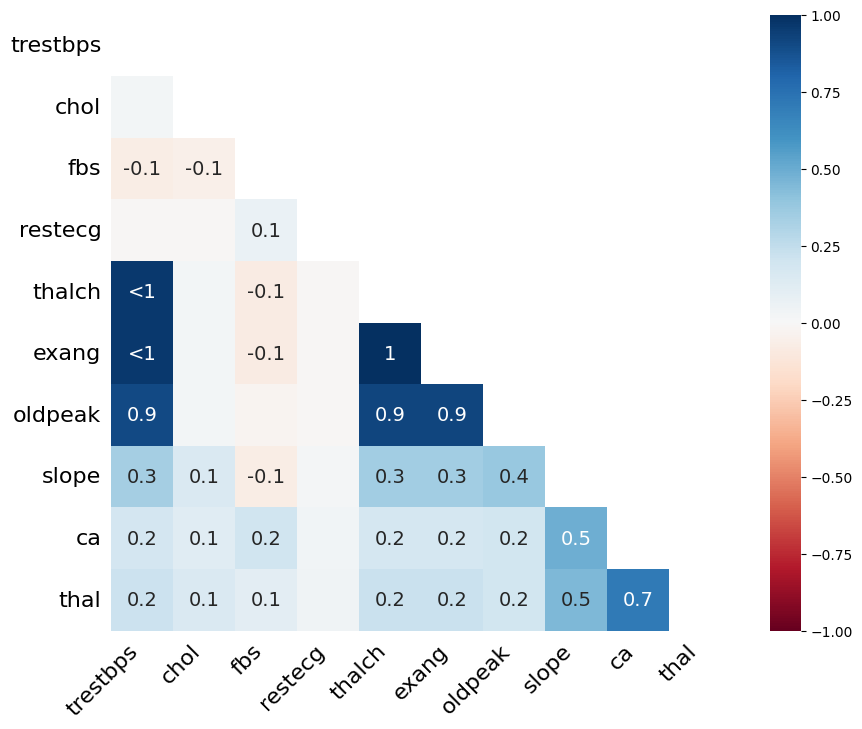

In [5]:
import missingno as msno
msno.matrix(df, figsize=(12, 6))
msno.heatmap(df, figsize=(10, 8))

The missingness pattern is non-random and clinically structured. Features thalch, exang, and oldpeak exhibit near-perfect co-missingness (r=0.9–1.0), confirming they derive from exercise stress testing — absent when the procedure was not performed. Similarly, ca and thal co-occur in missingness (r=0.7), both requiring invasive cardiac catheterization or nuclear imaging. This pattern is consistent with Missing At Random (MAR) conditioned on institution and clinical protocol, not random data loss.

## Dataset Variables 

The dataset contains 920 patients from 4 different institutions and 16 variables:

| Variable | Type | Clinical Description |
|----------|------|-------------------|
| `id` | int | Unique patient identifier. No predictive value. |
| `age` | int | Age in years. Well-established cardiovascular risk factor. |
| `sex` | str | Biological sex: Male / Female. Men face higher risk at younger ages. |
| `dataset` | str | Source institution: Cleveland, Hungary, Switzerland, VA Long Beach. |
| `cp` | str | Chest pain type: typical angina, atypical angina, non-anginal, asymptomatic. Asymptomatic pain is paradoxically the most associated with severe disease. |
| `trestbps` | float | Resting blood pressure at hospital admission (mm Hg). Hypertension is a major risk factor. |
| `chol` | float | Serum cholesterol (mg/dl). High levels associated with arterial plaque buildup. |
| `fbs` | object | Fasting blood sugar > 120 mg/dl: True/False. Indicates diabetes, a critical comorbidity. |
| `restecg` | str | Resting electrocardiogram results: normal, ST-T wave abnormality, left ventricular hypertrophy. |
| `thalch` | float | Maximum heart rate achieved during stress test. Lower capacity = higher risk. |
| `exang` | object | Exercise-induced angina: True/False. Pain triggered by exertion signals ischemia. |
| `oldpeak` | float | ST segment depression induced by exercise relative to rest. Indicates myocardial ischemia. |
| `slope` | str | Slope of the peak exercise ST segment: upsloping, flat, downsloping. Downsloping is the most concerning. |
| `ca` | float | Number of major vessels colored by fluoroscopy (0-3). More obstructed vessels = greater severity. |
| `thal` | str | Thallium stress test result (blood flow to heart): normal, fixed defect, reversible defect. |
| `num` | int | **Target variable.** Heart disease diagnosis: 0 = absent, 1-4 = present (severity). |


Age is the most important risk factor in developing cardiovascular or heart diseases, with approximately a tripling of risk with each decade of life. Coronary fatty streaks can begin to form in adolescence. It is estimated that 82 percent of people who die of coronary heart disease are 65 and older. Simultaneously, the risk of stroke doubles every decade after age 55.

Men are at greater risk of heart disease than pre-menopausal women. Once past menopause, it has been argued that a woman’s risk is similar to a man’s although more recent data from the WHO and UN disputes this. If a female has diabetes, she is more likely to develop heart disease than a male with diabetes.

In [6]:
print(df['num'].value_counts())
print(df.columns.tolist())

num
0    411
1    265
2    109
3    107
4     28
Name: count, dtype: int64
['id', 'age', 'sex', 'dataset', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalch', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'num']


## Target Variable Binarization

The original `num` variable encodes coronary artery disease severity 
on a 0–4 scale based on angiographic findings. We binarize it to a 
binary outcome (0 = no disease, 1 = disease present) for three reasons:

1. **Clinical threshold**: The medically established criterion for 
   significant CAD is ≥50% diameter narrowing of a major vessel 
   (Detrano et al., 1989). This threshold is inherently binary — 
   it defines whether clinical intervention is warranted.

2. **Class imbalance**: num=4 contains only 28 cases (3.0%), 
   insufficient for reliable multiclass learning. Binarization 
   concentrates statistical power on the clinically meaningful 
   distinction.

3. **Literature consistency**: Binary classification is the standard 
   formulation in published work on this dataset, enabling direct 
   comparison with prior results.

The resulting distribution is 411 negative (44.7%) vs 509 positive 
(55.3%) — approximately balanced, reflecting the referral population 
at the contributing institutions.

In [7]:
# Binarizar target
df['target'] = (df['num'] > 0).astype(int)  #1= symptomatyc 0= asymptomathyc

# Verificar
print(df['target'].value_counts())
print(df['target'].value_counts(normalize=True).round(3))

target
1    509
0    411
Name: count, dtype: int64
target
1    0.553
0    0.447
Name: proportion, dtype: float64


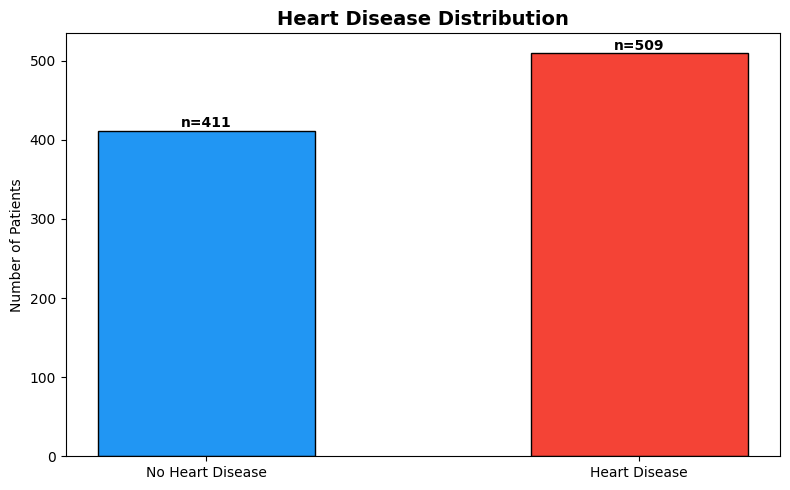

In [8]:
#SEPARATE FROM MAN AND WOMAN WITH HEART DISEASE
fig, ax = plt.subplots(figsize=(8, 5))

# Count patients in each class and sort by index (0 first, then 1)
target_counts = df['target'].value_counts().sort_index()

# Draw the bar chart
# - X axis labels: human-readable disease status
# - Y axis values: patient counts per class
# - Blue for no disease, red for disease (standard medical convention)
# - Black edges and width=0.5 for clean readability
ax.bar(
    ['No Heart Disease', 'Heart Disease'],
    target_counts.values,
    color=['#2196F3', '#F44336'],
    edgecolor='black',
    width=0.5
)

# Labels and title
ax.set_title('Heart Disease Distribution', fontsize=14, fontweight='bold')
ax.set_ylabel('Number of Patients')

# Add count labels on top of each bar
# enumerate() gives us both index (i = x position) and value (v = bar height)
# v + 5 places the text slightly above the bar
# (0, 411)   → i=0, v=411
# (1, 509)   → i=1, v=509
for i, v in enumerate(target_counts.values):
    ax.text(i, v + 5, f'n={v}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

## 3.1 Target Variable Distribution

The dataset contains 411 patients without significant CAD (44.7%) and 
509 with CAD present (55.3%), yielding an approximately balanced 
class distribution.

However, this prevalence does not reflect the general population 
(~6-7% CAD prevalence). All 920 patients were referred for coronary 
angiography — meaning clinicians already suspected disease prior to 
testing. This referral bias explains the elevated positive rate and 
is a critical limitation for generalization to screening settings.

In [9]:
# Filtrar primero por sexo, luego contar target
male_counts = df[df['sex'] == 'Male']['target'].value_counts().sort_index()
female_counts = df[df['sex'] == 'Female']['target'].value_counts().sort_index()
print("male analysis")
print(male_counts)
print("female analysis")
print(female_counts)

male analysis
target
0    267
1    459
Name: count, dtype: int64
female analysis
target
0    144
1     50
Name: count, dtype: int64


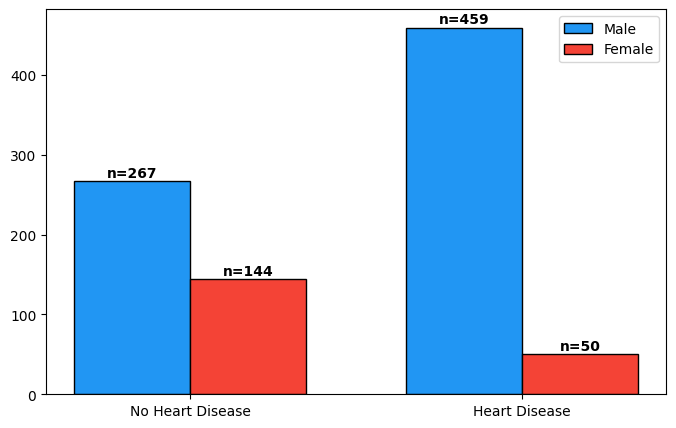

In [15]:
import numpy as np

male_counts = df[df['sex'] == 'Male']['target'].value_counts().sort_index()
female_counts = df[df['sex'] == 'Female']['target'].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(8, 5)) 
x = np.arange(2)  # 2 grupos: No Disease, Disease
width = 0.35

ax.bar(x - width/2, male_counts.values, width, label='Male', color='#2196F3', edgecolor='black')
ax.bar(x + width/2, female_counts.values, width, label='Female', color='#F44336', edgecolor='black')

# Male labels → misma posición que ax.bar para male: x - width/2
for i, v in enumerate(male_counts.values):
    ax.text(x[i] - width/2, v + 5, f'n={v}', ha='center', fontweight='bold')

# Female labels → misma posición que ax.bar para female: x + width/2
for i, v in enumerate(female_counts.values):
    ax.text(x[i] + width/2, v + 5, f'n={v}', ha='center', fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(['No Heart Disease', 'Heart Disease'])
ax.legend()
plt.show()


Resources I used:



https://www.kaggle.com/code/muhammadhanzla1234/heart-disease-prediction-with-77-55-accuracy#Context

https://www.kaggle.com/code/hussain99/heart-disease-prediction-10-models-eda